  Processing phase: p2
    Processing withknee: 
      Processing subject: CC120049
      Processing subject: CC120065
      Processing subject: CC120218
      Processing subject: CC120470
      Processing subject: CC120640
      Processing subject: CC120795
      Processing subject: CC121428
      Processing subject: CC210023
      Processing subject: CC210088
      Processing subject: CC220107
      Processing subject: CC220335
      Processing subject: CC220419
      Processing subject: CC220518
      Processing subject: CC220519
      Processing subject: CC220828
      Processing subject: CC220974
      Processing subject: CC221002
      Processing subject: CC221487
      Processing subject: CC221585
      Processing subject: CC221977
      Processing subject: CC222258
      Processing subject: CC222264
      Processing subject: CC222496
      Processing subject: CC222652
      Processing subject: CC223286
      Processing subject: CC310051
      Processing subject: CC310086
      

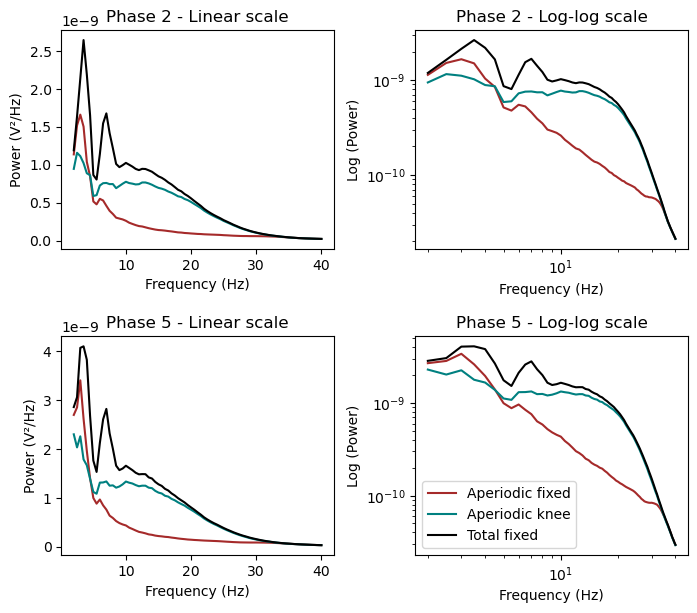

In [ ]:
"""
Script to generate source data for Supplementary Figure 6, with ECG total and aperiodic spectra with/without knee in both linear and log-log scales (for each experimental Phase).
"""
import pandas as pd
import numpy as np
import mne
import os

datadir = os.path.abspath(os.path.join(os.path.dirname( os.getcwd() ), '.', 'data'))
print(f'Data directory: {datadir}')

maindir = ''

pipver = ''
task = 'rest'
phases = ['p2', 'p5']

lfreq = 0.1 #Hz
hfreq = 145.0 #Hz
fsample = 300.0 #Hz
frange = f"{round(lfreq, 1)}-{int(hfreq)}Hz"

trans = True # Whether to use head transformation or not
zmm = 44 # destination z coordinate head position in mm

cropdata = 532 
epoch_duration = 2  # in seconds
powmethod = 'WL'  # 'MT'  'WL'

psddesc = f'dur{cropdata}sepo{epoch_duration}s{powmethod}'

# ---- File with subjects and arms ----
subjlistfile = os.path.join(datadir,f'meglong_{task}_subjects.tsv')

normalize_psd = False
snorm = '_normalized' if normalize_psd else ''

psd_deriv_folder = f'mne-bids-pipeline_{pipver}_filt{frange}_fs{int(fsample)}Hz_trans_z{zmm}mm'
goodepochs_deriv_folder = psd_deriv_folder

subjectsdf = pd.read_csv(subjlistfile, sep='\t', index_col=0)
subjects = subjectsdf.index.tolist()

phases_dict = {
    'p2': {'label': 'Phase 2', 'color': 'deepskyblue'},
    'p5': {'label': 'Phase 5', 'color': 'deeppink'}
}

proc = 'sssECG'
psd_deriv_folder = f'mne-bids-pipeline_stier_filt{frange}_fs{int(fsample)}Hz'

normalize_psd = False
snorm = '_normalized' if normalize_psd else ''


def get_powerunits(megtype):
    id = subjects[0]
    armx = subjectsdf.loc[id,'arm']        

    # --- Define the psd directory and file ---
    bids_project_folder = f'BIDS_long_{phase}_{task}_arm{armx}'
    psd_derivdir = os.path.join(maindir, bids_project_folder,
            'derivatives', psd_deriv_folder)
    psd_megdir = os.path.join(psd_derivdir, 'sub-'+id, 'meg')

    psdfilename = f'sub-{id}_task-{task}_proc-{proc}_desc-{psddesc}_psd.hdf5'
    psdfile = os.path.join(psd_megdir, psdfilename)

    # --- Read the power spectrum data ---
    psd = mne.time_frequency.read_spectrum(psdfile)
    chan_units = psd.units()[megtype]
    return chan_units


# Folder containing the psds of total and aperiodic spectra with and without knee, for ECG channel
aper_deriv_folder = f'aperiodic_filt{frange}_fs{int(fsample)}Hz'
fitting_param = 'finley' 

plot_freqs = None

m = -1

for p, phase in enumerate(phases):
    print(f'  Processing phase: {phase}')
    m += 1

    if normalize_psd:
        chan_units = '(normalized, a.u.)'
    else:
        chan_units = get_powerunits('ecg')

    plot_spectra = []

    for withknee in ['', 'knee', 'total']:
        print(f'    Processing withknee: {withknee}')
        all_subj_spectra = []

        # loop over all subjects
        for id in subjectsdf.index.tolist(): # limit to 2 subjects for testing
            armx = subjectsdf.loc[id,'arm']  
            print(f'      Processing subject: {id}')      
        
            # --- Define the psd directory and file ---
            bids_project_folder = f'BIDS_long_{phase}_{task}_arm{armx}'
            psd_derivdir = os.path.join(maindir, bids_project_folder,
                    'derivatives', aper_deriv_folder)
            psd_megdir = os.path.join(psd_derivdir, 'sub-'+id, 'meg')

            if withknee == 'total':
                psdfilename = f'sub-{id}_task-{task}_proc-{proc}_desc-{psddesc}{fitting_param}_specparam_total.npy'

            else:
                psdfilename = f'sub-{id}_task-{task}_proc-{proc}_desc-{psddesc}{fitting_param}{withknee}_specparam_aperiodic.npy'

            psdfile = os.path.join(psd_megdir, psdfilename)

            # --- Read the power spectrum data ---
            psd = np.load(psdfile, allow_pickle=True).item()
            spectra = psd['spectra']  # epochs x channels x frequencies
            freqs = psd['freqs']

            # --- Average PSD across channels ---
            spectra = np.average(spectra, axis=0)  # average across channels

            if normalize_psd:
                spectra = spectra / np.trapezoid(spectra, freqs)  # normalize PSD by total power

            all_subj_spectra.append(spectra.copy())

            if plot_freqs is None:
                plot_freqs = freqs

            del spectra, freqs

        # Average across subjects
        plot_spectra.append(np.mean(all_subj_spectra, axis=0)) # average across subjects
        del all_subj_spectra # free memory

    source_data_dict = {
        'freqs': plot_freqs,
        'aperiodic_fixed': plot_spectra[0],
        'aperiodic_knee': plot_spectra[1],
        'total_fixed': plot_spectra[2],
        'units': chan_units,
    }

    source_df = pd.DataFrame(source_data_dict)

    # Save source data to CSV, to then plot Supplementary Figure 3 with supp_figure03_script.ipynb
    source_df.to_csv(os.path.join(datadir, f'supp_figure06_{phase}_source_data.csv'), index=False, encoding='utf-8-sig')
